In [2]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Task 1 - Baseline Study

### Task 1.1 - Data preparation and validation pipeline 

**Concrete Segmentation Question (RQ1)**

RQ1: "Are there natural, distinct segments of guests that differentiate short-stay individual/business travelers from long-stay family or leisure groups based on their group composition and weekend/weekday stay patterns?"

**Unit of Analysis**

Unit of Analysis: A single hotel booking.

**Short Data Documentation**

Source: The "Hotel Booking Demand" dataset, originally published by António, de Almeida, and Nunes (2019). It contains real-world Property Management System (PMS) data from two hotels in Portugal: a Resort Hotel (Algarve) and a City Hotel (Lisbon). We are using the specific course release version (hotel_bookings_course_release_v1.csv).

License/Terms: The dataset is open and provided for academic/educational purposes, with identifiers removed or anonymized as documented in the original reference paper.

What each row represents: Each row corresponds to one individual booking (regardless of whether the booking ultimately arrived or was canceled).

Time Span: The data covers bookings with arrival dates spanning from July 1, 2015, to August 31, 2017.

Known Data Quality Issues: 
1. Missing Values: There is a minor missingness issue in the children attribute (4 missing records).
2. Extreme Outliers: The exploratory data analysis (EDA) revealed severe outliers in numerical variables (e.g., a maximum of 55 adults in a single booking, and up to 50 stays_in_week_nights). These represent a significant quality issue for distance-based clustering (like K-Means) and require heuristic filtering before standardization.
3. Information Leakage: The dataset includes post-booking/outcome variables (such as is_canceled and reservation_status) that act as "leakage" and must be strictly excluded from the feature set used to train the unsupervised models.

In [3]:
df = pd.read_csv('hotel_bookings_course_release_v1.csv')

print(f"Initial dataset dimensions: {df.shape[0]} rows and {df.shape[1]} columns.\n")

Initial dataset dimensions: 119390 rows and 32 columns.



In [4]:
# LEAKEGE CONTROL

num_features = ['adults', 'children', 'babies', 'stays_in_weekend_nights', 'stays_in_week_nights']
cat_features = ['hotel']

df_analysis = df[num_features + cat_features].copy()

In [5]:
# ANALYSIS AND REPORTS

print("--- Missing Values Report ---")
missing_report = df_analysis.isnull().sum()
print(missing_report[missing_report > 0])
print("\nConclusion: Only the 'children' variable has missing values (4 occurrences).\n")

print("--- Outliers Report ---")
desc_stats = df_analysis[num_features].describe()
print(desc_stats.loc[['min', '50%', '75%', 'max']])
print("\nConclusion: Extreme outliers are observed, such as 'adults' with a maximum of 55 and " \
"'stays_in_week_nights' with 50. Since Euclidean Distance is sensitive to scale and extreme values, " \
"these need to be removed.")

--- Missing Values Report ---
children    4
dtype: int64

Conclusion: Only the 'children' variable has missing values (4 occurrences).

--- Outliers Report ---
     adults  children  babies  stays_in_weekend_nights  stays_in_week_nights
min     0.0       0.0     0.0                      0.0                   0.0
50%     2.0       0.0     0.0                      1.0                   2.0
75%     2.0       0.0     0.0                      2.0                   3.0
max    55.0      10.0    10.0                     19.0                  50.0

Conclusion: Extreme outliers are observed, such as 'adults' with a maximum of 55 and 'stays_in_week_nights' with 50. Since Euclidean Distance is sensitive to scale and extreme values, these need to be removed.


In [6]:
# OUTLIER TREATMENT (Heuristic Filter)
print("--- Removal of Extreme Outliers ---")
# We apply a common-sense (domain) filter to avoid distorting the centroids in K-Means
adults_filter = df_analysis['adults'] <= 10
nights_filter = df_analysis['stays_in_week_nights'] <= 20
babies_filter = df_analysis['babies'] <= 5

df_clean = df_analysis[adults_filter & nights_filter & babies_filter].copy()

removed_outliers = len(df_analysis) - len(df_clean)
print(f"{removed_outliers} anomalous bookings were removed.")
print(f"Clean dataset ready for the Pipeline: {len(df_clean)} rows.\n")


--- Removal of Extreme Outliers ---
60 anomalous bookings were removed.
Clean dataset ready for the Pipeline: 119330 rows.



In [7]:
# PREPROCESSING PIPELINE

print("--- Pipeline Construction and Application ---")

# Numerical Pipeline: Median imputation (for 'children') + Z-score Scaling
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline: Mode imputation + One-Hot Encoding
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer: Joins both pipelines applying them to the respective columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ])

# Fit and Transform on the clean data
X_processed = preprocessor.fit_transform(df_clean)

# Get the final feature names (useful for later interpretation)
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
encoded_cat_names = cat_encoder.get_feature_names_out(cat_features)
final_feature_names = num_features + list(encoded_cat_names)

print(f"Final X_processed matrix dimensions: {X_processed.shape}")
print(f"Final features: {final_feature_names}")

--- Pipeline Construction and Application ---
Final X_processed matrix dimensions: (119330, 7)
Final features: ['adults', 'children', 'babies', 'stays_in_weekend_nights', 'stays_in_week_nights', 'hotel_City Hotel', 'hotel_Resort Hotel']


### Task 1.2

In [8]:
# K-MEANS BASELINE EXECUTION OVER THE K RANGE

print("--- K-Means Baseline Evaluation ---")

k_range = range(3, 7) # k varies from 3 to 6
kmeans_results = []

for k in k_range:
    start_time = time.time()
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = kmeans.fit_predict(X_processed)
    runtime = time.time() - start_time
    sil_score = silhouette_score(X_processed, labels, sample_size=20000, random_state=42)
    inertia = kmeans.inertia_
    
    kmeans_results.append({
        'k': k,
        'Inertia': inertia,
        'Silhouette': sil_score,
        'Runtime (s)': runtime,
        'Model': kmeans,
        'Labels': labels
    })
    print(f"k={k} | Silhouette: {sil_score:.4f} | Inertia: {inertia:.2f} | Runtime: {runtime:.2f}s")


--- K-Means Baseline Evaluation ---
k=3 | Silhouette: 0.3312 | Inertia: 419729.73 | Runtime: 3.32s
k=4 | Silhouette: 0.3507 | Inertia: 325216.27 | Runtime: 0.18s
k=5 | Silhouette: 0.3845 | Inertia: 245879.71 | Runtime: 0.17s
k=6 | Silhouette: 0.3456 | Inertia: 208173.19 | Runtime: 0.23s


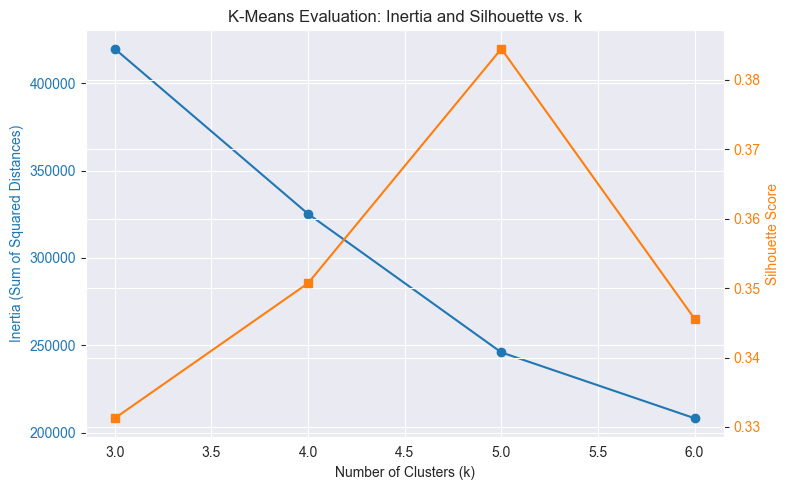

In [9]:
# INTERNAL INDICES VISUALIZATION (Elbow & Silhouette)

inertia_vals = [res['Inertia'] for res in kmeans_results]
sil_vals = [res['Silhouette'] for res in kmeans_results]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Inertia (Left Y-axis)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)', color=color)
ax1.plot(k_range, inertia_vals, marker='o', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

# Plot Silhouette (Right Y-axis)
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, sil_vals, marker='s', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Evaluation: Inertia and Silhouette vs. k')
fig.tight_layout()
plt.show()



In [12]:
# INITIAL INTERPRETATION OF CLUSTER PROFILES

best_k = 4
print(f"\n--- Initial Cluster Profiles for the chosen model (k={best_k}) ---")

# Correspondent model for k=4
best_result = next(item for item in kmeans_results if item["k"] == best_k)
best_model = best_result['Model']
best_labels = best_result['Labels']

df_profiling = df_clean.copy()
df_profiling['Cluster'] = best_labels

# Calculate the mean of the original numerical variables (unscaled) per Cluster
num_features = ['adults', 'children', 'babies', 'stays_in_weekend_nights', 'stays_in_week_nights']
cluster_profiles = df_profiling.groupby('Cluster')[num_features].mean().round(2)

# Add the count of each cluster
cluster_profiles['Size (%)'] = (df_profiling['Cluster'].value_counts(normalize=True) * 100).round(1)

print(cluster_profiles)



--- Initial Cluster Profiles for the chosen model (k=4) ---
         adults  children  babies  stays_in_weekend_nights  \
Cluster                                                      
0          1.81      0.00    0.00                     0.60   
1          1.99      0.23    1.02                     1.16   
2          2.00      0.01    0.00                     2.18   
3          1.96      1.46    0.00                     1.05   

         stays_in_week_nights  Size (%)  
Cluster                                  
0                        1.86      73.9  
1                        3.01       0.8  
2                        4.94      18.5  
3                        2.68       6.9  


  k      ΔInertia    Silhouette  Runtime(s)
------------------------------------------
  4      94513.46        0.3507       0.183
  5      79336.56        0.3845       0.168
  6      37706.52        0.3456       0.229


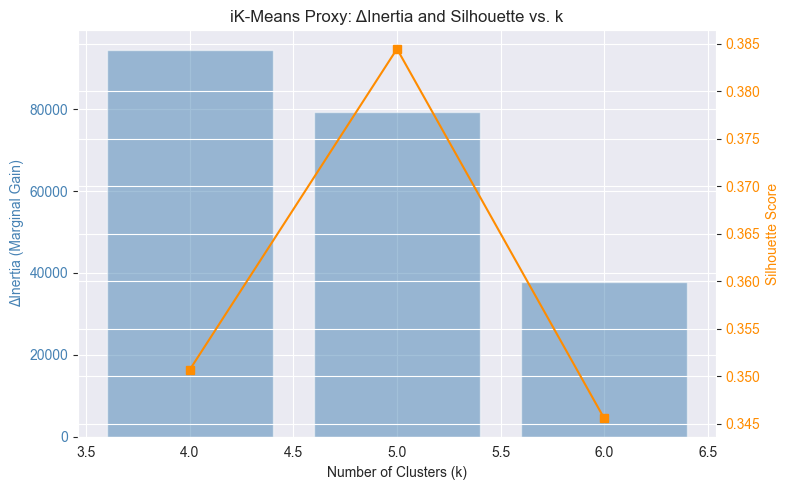


iK-Means suggests k=5: Bigger Silhouette and ΔInertia still relevant.


In [23]:
# iK-Means Evaluation (Placeholder)
# iK-Means stops adding clusters when the marginal inertia gain becomes small.

print(f"{'k':>3}  {'ΔInertia':>12}  {'Silhouette':>12}  {'Runtime(s)':>10}")
print("-" * 42)
for i in range(1, len(kmeans_results)):
    r = kmeans_results[i]
    delta = kmeans_results[i-1]['Inertia'] - r['Inertia']
    print(f"{r['k']:>3}  {delta:>12.2f}  {r['Silhouette']:>12.4f}  {r['Runtime (s)']:>10.3f}")

ks_d   = [r['k'] for r in kmeans_results[1:]]
deltas = [kmeans_results[i-1]['Inertia'] - kmeans_results[i]['Inertia']
          for i in range(1, len(kmeans_results))]
sils_d = [r['Silhouette'] for r in kmeans_results[1:]]

fig, ax1 = plt.subplots(figsize=(8, 5))

# ΔInertia (left axis)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('ΔInertia (Marginal Gain)', color='steelblue')
ax1.bar(ks_d, deltas, color='steelblue', alpha=0.5, label='ΔInertia')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Silhouette (right axis)
ax2 = ax1.twinx()
ax2.set_ylabel('Silhouette Score', color='darkorange')
ax2.plot(ks_d, sils_d, marker='s', color='darkorange', label='Silhouette')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('iK-Means: ΔInertia and Silhouette vs. k')
fig.tight_layout()
plt.show()

print("\niK-Means suggests k=5: Bigger Silhouette and ΔInertia still relevant.")

# Task 2 - Alternative Clustering Family

## 2.1 Development